In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kanchana1990/global-scientific-retractions-19272026/global_scientific_retractions_1927_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/kanchana1990/global-scientific-retractions-19272026/global_scientific_retractions_1927_2026.csv")

In [3]:
df.head()

,record_id,title,journal,publisher,country,author,subject,articletype,reason,retractiondate,...,years_to_retraction,institution,author_count,reason_count,subject_count,title_len,title_word_count,has_retraction_doi,has_original_doi,row_quality_flag
0,17246,The Trend-Seasonal Normal in Time Series,Journal of the American Statistical Association,Taylor and Francis,United States,C H Whelden Jr,(ENV) Climatology;,Review Article;,Error in Analyses;,4/1/1927,...,0.999316,Yale University,1,1,1,40,6,0,0,OK
1,18531,Naturwissenschaft und reale Aussenwelt,Die Naturwissenschaften,Springer,Germany,Max Planck,(PHY) Physics;(SOC) Philosophy;,Review Article;,Copyright Claims;Date of Article and/or Notice...,12/1/1940,...,0.000000,Berlin,1,2,2,38,4,1,1,OK
2,18529,Sinn und Grenzen der exakten Wissenschaft,Die Naturwissenschaften,Springer,Germany,Max Planck,(PHY) Physics;,Review Article;,Copyright Claims;Date of Article and/or Notice...,2/1/1942,...,0.000000,Berlin,1,2,1,41,6,1,1,OK
3,10433,Change of Venue and the Conflict of Laws,The University of Chicago Law Review,University of Chicago Law School,United States,Brainerd Currie,(SOC) Law/Legal Issues;,Research Article;,Error in Results and/or Conclusions;Unreliable...,2/1/1960,...,4.999316,University of Chicago;,1,2,1,40,8,0,0,OK
4,825,On the Primary Site of Nuclear RNA Synthesis,The Journal of Cell Biology,Rockefeller University Press,United States,Louise M Luckenbill;Alan S Cohen,(BLS) Biology - Cellular;(BLS) Biology - Gener...,Research Article;,Error in Results and/or Conclusions;Results No...,10/1/1966,...,7.000684,Department of Biology University of Pennsylvan...,2,2,4,44,8,1,1,OK


In [4]:
df.tail()

,record_id,title,journal,publisher,country,author,subject,articletype,reason,retractiondate,...,years_to_retraction,institution,author_count,reason_count,subject_count,title_len,title_word_count,has_retraction_doi,has_original_doi,row_quality_flag
64262,69957,The Simulation of Bracciano Lake (Central Ital...,Environmental Processes,Springer - Nature Publishing Group,Italy,Francesco Maria De Filippi;Giuseppe Sappa,(ENV) Climate Change;(ENV) Environmental Scien...,Research Article;,Error in Data;,3/21/2026,...,2.108145,"Department of Civil, Construction and Environm...",2,1,3,179,26,1,1,OK
64263,69908,Cosmetic Talc Powder,Lancet,Elsevier,Unknown,Anonymous,(BLS) Toxicology;(HSC) Public Health and Safety;,Commentary/Editorial;Letter;,Concerns/Issues about Authorship/Affiliation;C...,3/25/2026,...,48.747433,Unavailable,1,5,2,20,3,1,1,OK
64264,69935,Oral Diclofenac Potassium Versus Hyoscine-N-Bu...,Journal of Minimally Invasive Gynecology,Elsevier,Egypt;Libya,Ahmed Mohamed Abbas;Ahmed M Elzargha;Abdel Gha...,(HSC) Medicine - Anesthesia/Anaesthesia;(HSC) ...,Clinical Study;,Author Unresponsive;Concerns/Issues about Data...,3/25/2026,...,6.918549,"Department of Obstetrics and Gynecology, Facul...",6,10,4,163,17,1,1,OK
64265,69937,Efficacy of ferrous bis-glycinate versus ferro...,The Journal of Maternal-Fetal & Neonatal Medicine,Taylor and Francis,Egypt,Ahmed Mohamed Abbas;Safaa A Abdelbadee;Ahmed A...,(BLS) Biochemistry;(HSC) Medicine - Obstetrics...,Clinical Study;,Author Unresponsive;Concerns/Issues about Data...,3/26/2026,...,7.764545,"Department of Obstetrics & Gynecology, Faculty...",4,6,3,164,22,1,1,OK
64266,69940,Vaginal suppositories of cumin seeds essential...,European Journal of Pharmaceutical Sciences,Elsevier,Egypt,Noura H Abd Ellah;Asmaa S Shaltout;Shreen M M ...,(BLS) Microbiology;(HSC) Medicine - Alternativ...,Research Article;,Author Unresponsive;Concerns/Issues about Anim...,3/29/2026,...,5.259411,"Department of Pharmaceutics, Faculty of Pharma...",9,12,4,144,20,1,1,OK


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64267 entries, 0 to 64266
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   record_id              64267 non-null  int64  
 1   title                  64267 non-null  object 
 2   journal                64267 non-null  object 
 3   publisher              64267 non-null  object 
 4   country                64267 non-null  object 
 5   author                 64267 non-null  object 
 6   subject                64267 non-null  object 
 7   articletype            64267 non-null  object 
 8   reason                 64267 non-null  object 
 9   retractiondate         64267 non-null  object 
 10  retraction_year        64267 non-null  int64  
 11  retractiondoi          59721 non-null  object 
 12  retractionpubmedid     59235 non-null  float64
 13  originalpaperdate      64267 non-null  object 
 14  original_year          64267 non-null  int64  
 15  or

In [6]:
df.describe()

,record_id,retraction_year,retractionpubmedid,original_year,originalpaperpubmedid,years_to_retraction,author_count,reason_count,subject_count,title_len,title_word_count,has_retraction_doi,has_original_doi
count,64267.000000,64267.000000,5.923500e+04,64267.000000,5.920200e+04,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000,64267.000000
mean,35121.063190,2018.560303,1.579884e+07,2016.216519,1.390603e+07,2.397444,4.075949,3.935643,2.729395,102.469152,13.614841,0.929264,0.908476
std,20469.435739,6.062955,1.727866e+07,6.435023,1.543258e+07,3.446243,3.068341,2.627242,1.166718,35.604484,4.723548,0.256386,0.288356
min,1.000000,1927.000000,0.000000e+00,1923.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16950.500000,2014.000000,0.000000e+00,2011.000000,0.000000e+00,0.391513,2.000000,2.000000,2.000000,78.000000,10.000000,1.000000,1.000000
50%,35156.000000,2021.000000,0.000000e+00,2018.000000,0.000000e+00,1.311431,3.000000,3.000000,3.000000,99.000000,13.000000,1.000000,1.000000
75%,53052.500000,2023.000000,3.577182e+07,2022.000000,3.076687e+07,2.806297,5.000000,5.000000,3.000000,123.000000,16.000000,1.000000,1.000000
max,69968.000000,2026.000000,4.190587e+07,2026.000000,4.146144e+07,81.100616,88.000000,17.000000,10.000000,384.000000,57.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

record_id                   0
title                       0
journal                     0
publisher                   0
country                     0
author                      0
subject                     0
articletype                 0
reason                      0
retractiondate              0
retraction_year             0
retractiondoi            4546
retractionpubmedid       5032
originalpaperdate           0
original_year               0
originalpaperdoi         5882
originalpaperpubmedid    5065
years_to_retraction         0
institution                 1
author_count                0
reason_count                0
subject_count               0
title_len                   0
title_word_count            0
has_retraction_doi          0
has_original_doi            0
row_quality_flag            0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['record_id', 'title', 'journal', 'publisher', 'country', 'author',
       'subject', 'articletype', 'reason', 'retractiondate', 'retraction_year',
       'retractiondoi', 'retractionpubmedid', 'originalpaperdate',
       'original_year', 'originalpaperdoi', 'originalpaperpubmedid',
       'years_to_retraction', 'institution', 'author_count', 'reason_count',
       'subject_count', 'title_len', 'title_word_count', 'has_retraction_doi',
       'has_original_doi', 'row_quality_flag'],
      dtype='object')

In [10]:
df.dtypes

record_id                  int64
title                     object
journal                   object
publisher                 object
country                   object
author                    object
subject                   object
articletype               object
reason                    object
retractiondate            object
retraction_year            int64
retractiondoi             object
retractionpubmedid       float64
originalpaperdate         object
original_year              int64
originalpaperdoi          object
originalpaperpubmedid    float64
years_to_retraction      float64
institution               object
author_count               int64
reason_count               int64
subject_count              int64
title_len                  int64
title_word_count           int64
has_retraction_doi         int64
has_original_doi           int64
row_quality_flag          object
dtype: object

In [11]:
df.shape

(64267, 27)

In [12]:
df.nunique()

record_id                64267
title                    64135
journal                   8409
publisher                 1683
country                   3179
author                   60262
subject                  16641
articletype                 94
reason                   10009
retractiondate            6022
retraction_year             59
retractiondoi            54983
retractionpubmedid       26979
originalpaperdate         7427
original_year               68
originalpaperdoi         58226
originalpaperpubmedid    28518
years_to_retraction       5218
institution              58876
author_count                45
reason_count                17
subject_count               10
title_len                  298
title_word_count            46
has_retraction_doi           2
has_original_doi             2
row_quality_flag             1
dtype: int64

## EDA

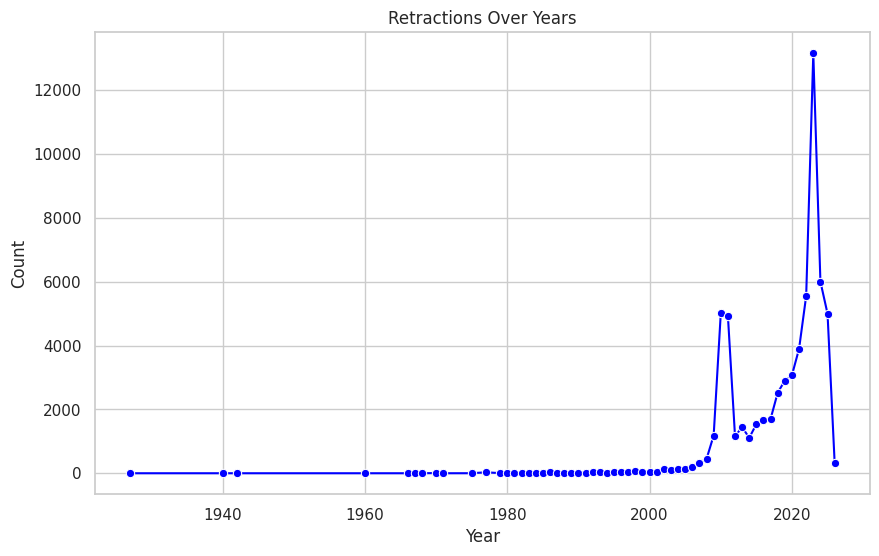

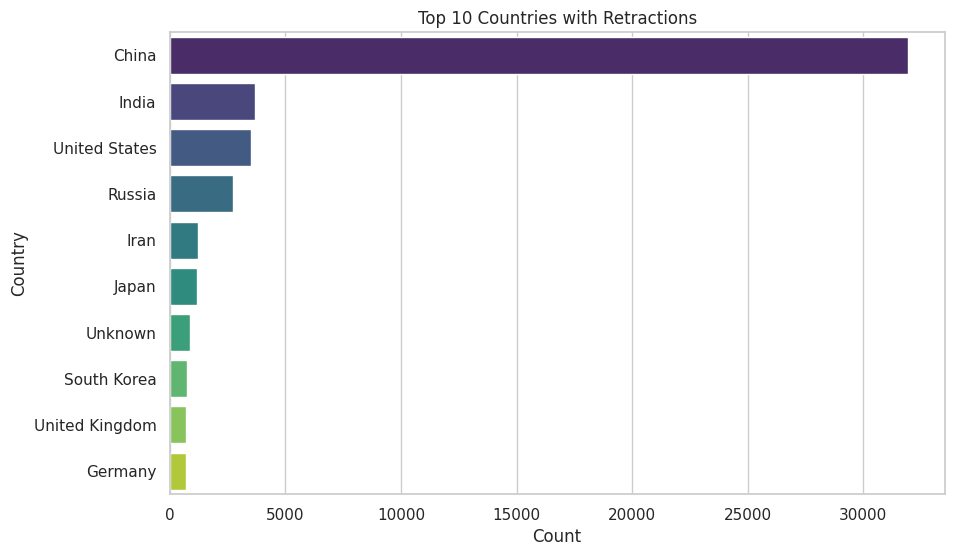

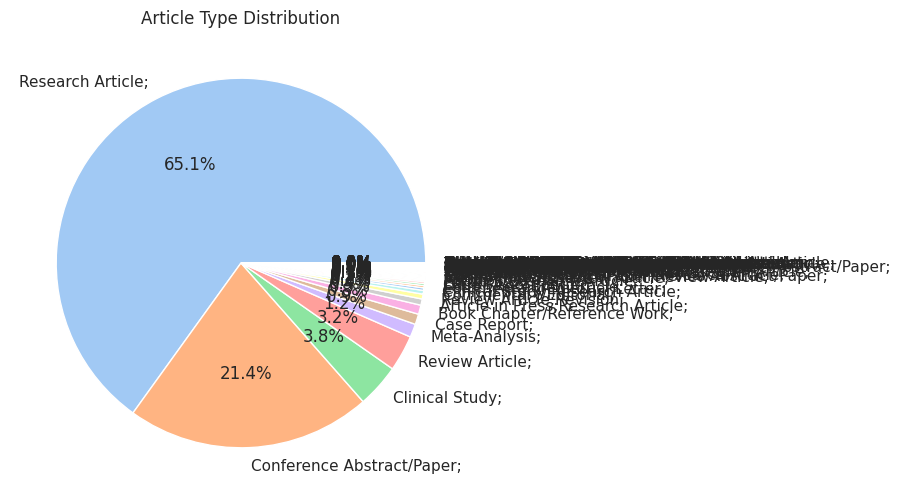

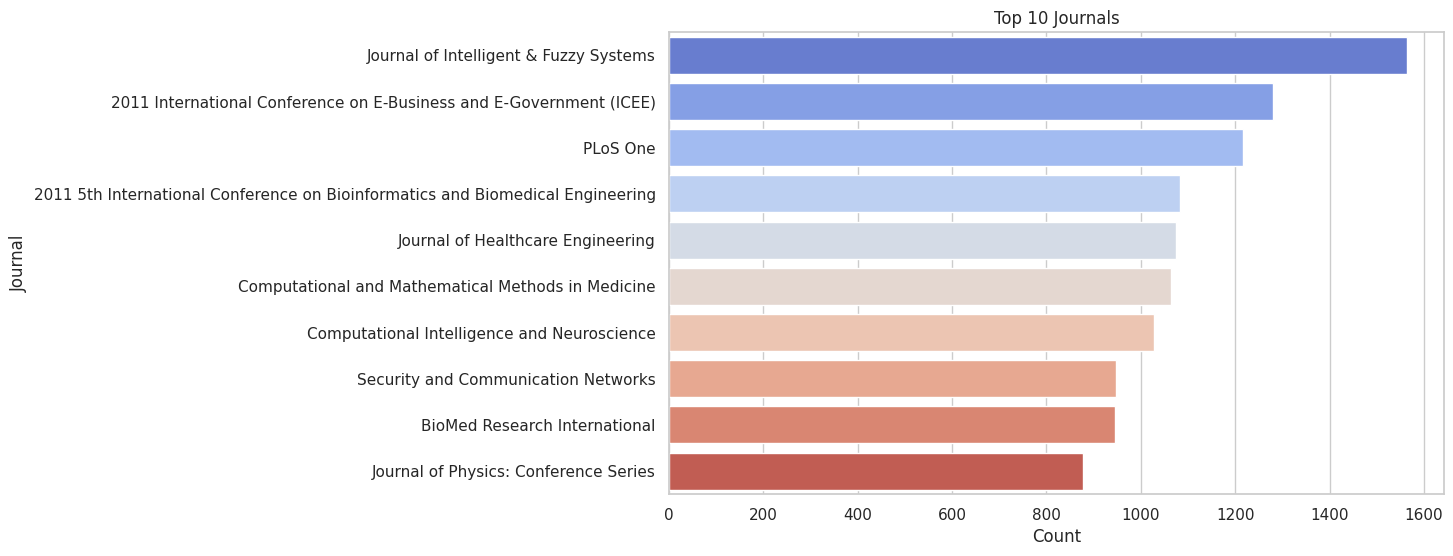

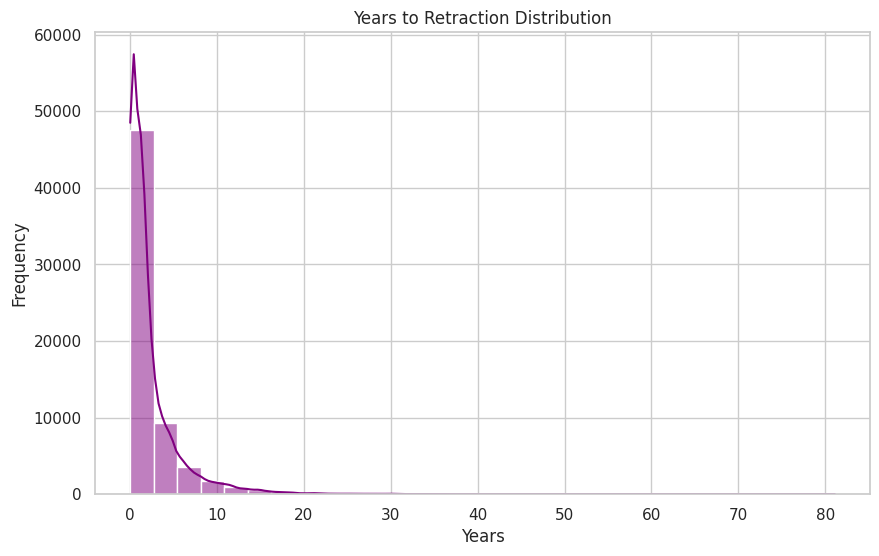

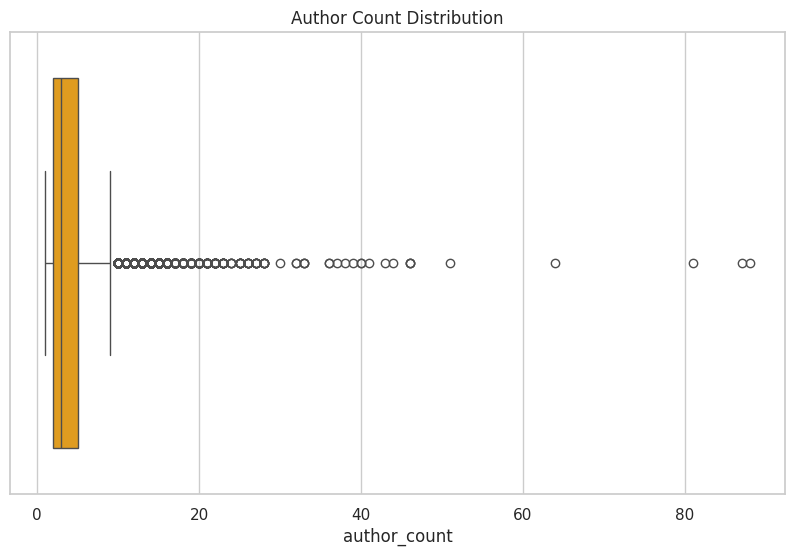

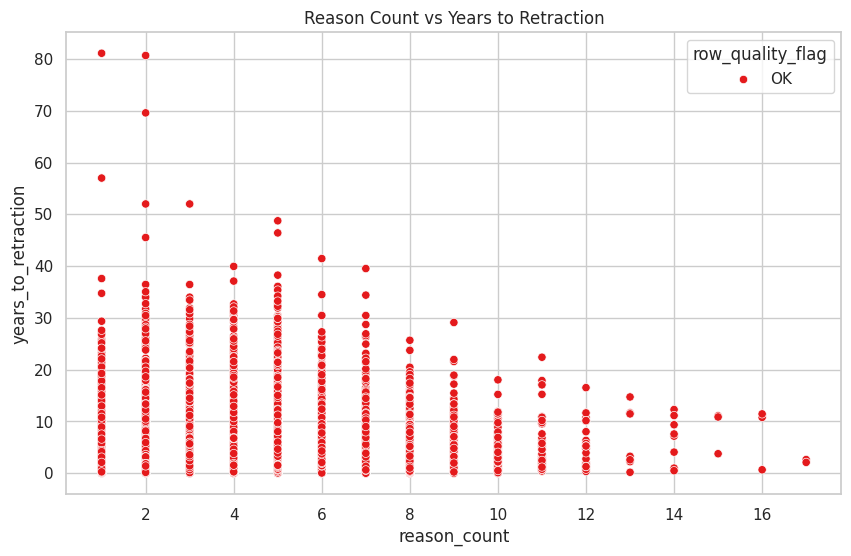

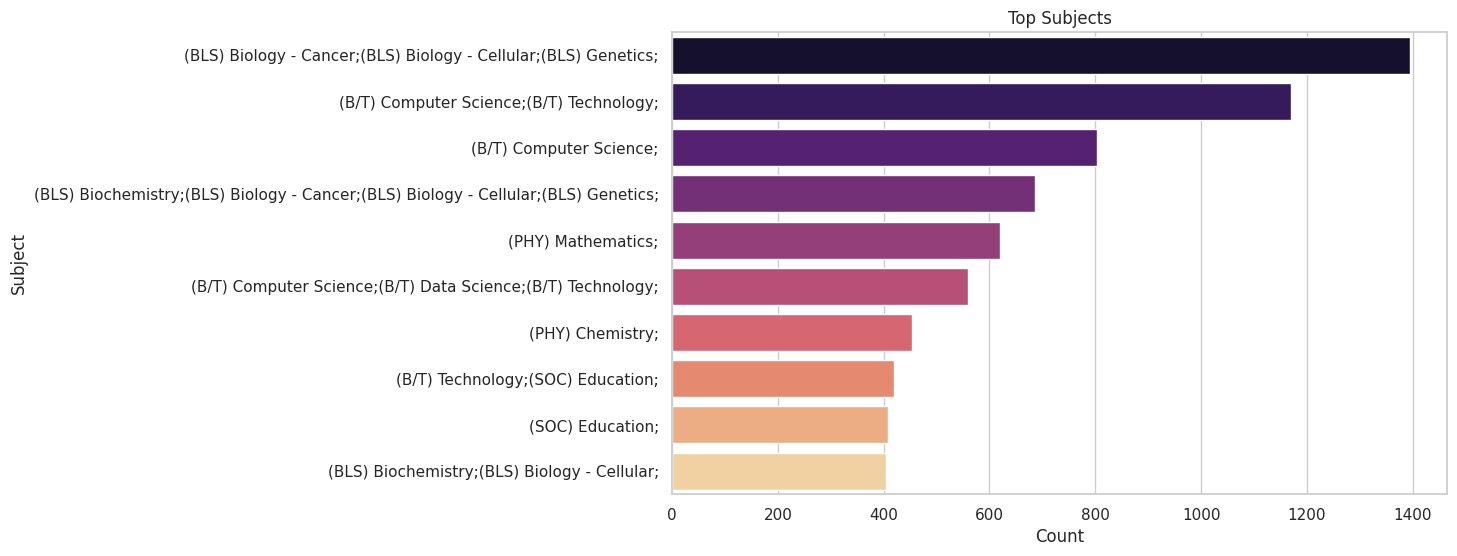

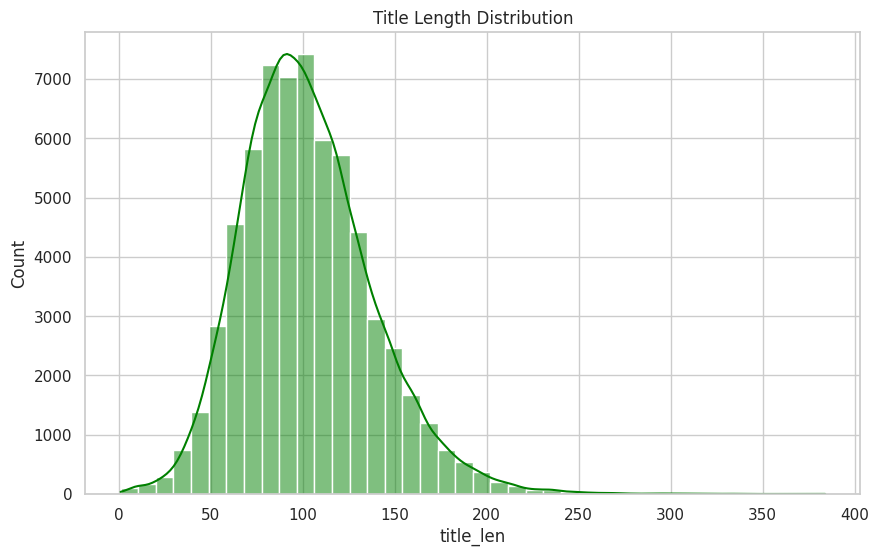

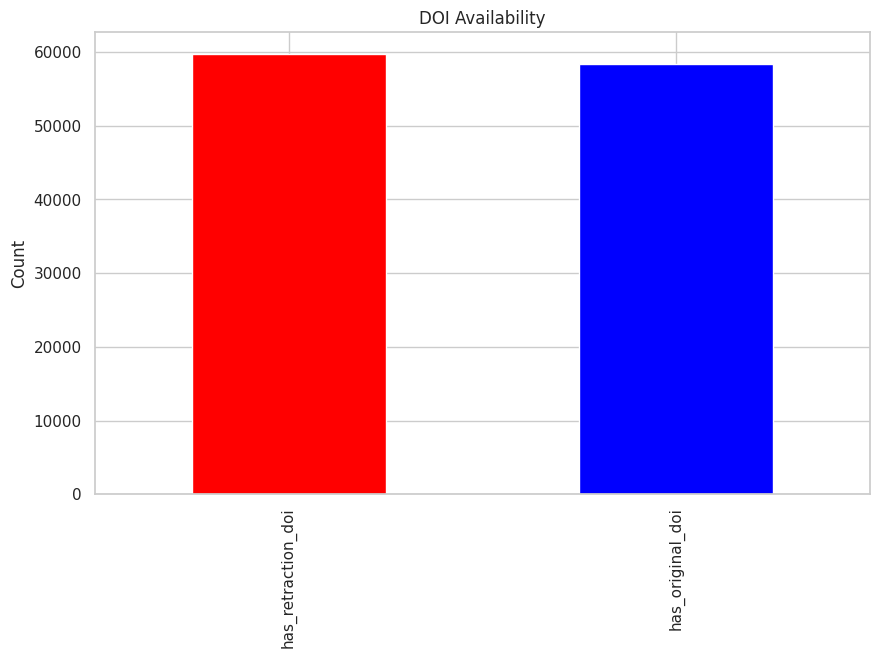

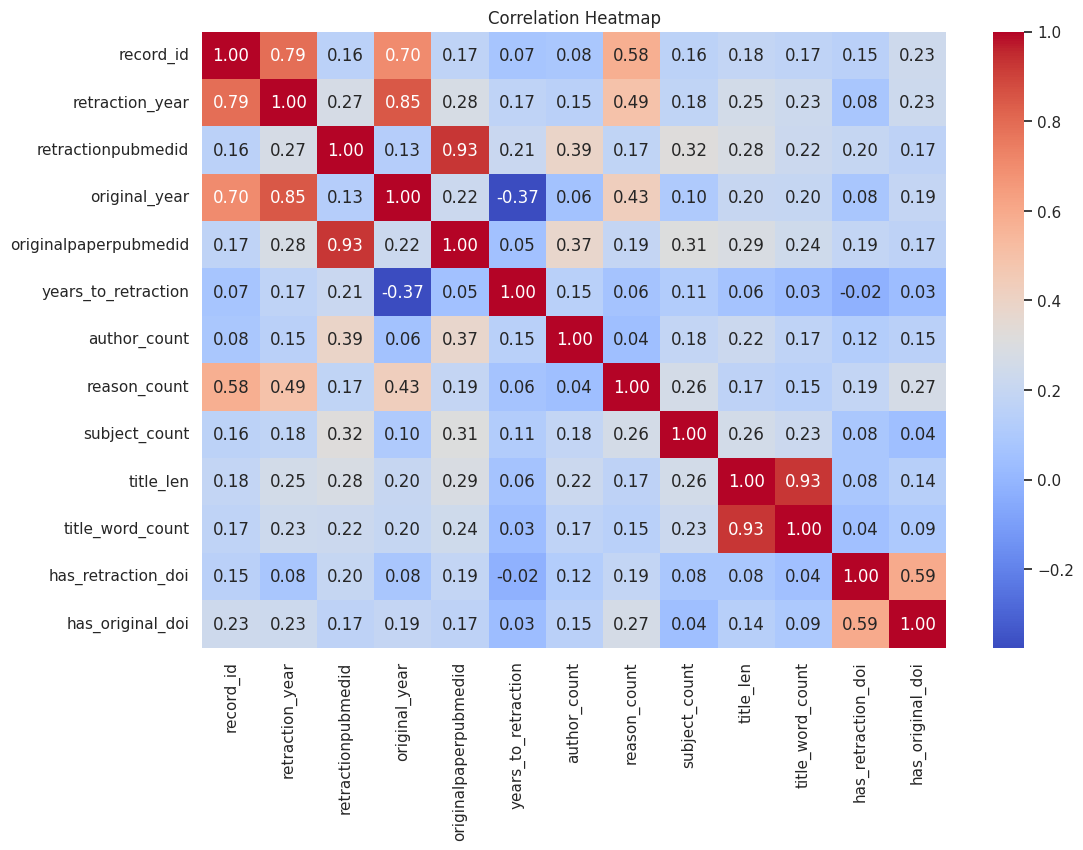

In [13]:

# ======================================
# BASIC SETTINGS
# ======================================
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ======================================
# 1. RETRACTIONS BY YEAR
# ======================================
plt.figure()
year_counts = df['retraction_year'].value_counts().sort_index()
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='blue')
plt.title("Retractions Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# ======================================
# 2. TOP 10 COUNTRIES
# ======================================
plt.figure()
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title("Top 10 Countries with Retractions")
plt.xlabel("Count")
plt.ylabel("Country")
plt.show()

# ======================================
# 3. ARTICLE TYPE DISTRIBUTION
# ======================================
plt.figure()
df['articletype'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=sns.color_palette('pastel')
)
plt.title("Article Type Distribution")
plt.ylabel('')
plt.show()

# ======================================
# 4. TOP JOURNALS
# ======================================
plt.figure()
top_journals = df['journal'].value_counts().head(10)
sns.barplot(x=top_journals.values, y=top_journals.index, palette='coolwarm')
plt.title("Top 10 Journals")
plt.xlabel("Count")
plt.ylabel("Journal")
plt.show()

# ======================================
# 5. YEARS TO RETRACTION DISTRIBUTION
# ======================================
plt.figure()
sns.histplot(df['years_to_retraction'], bins=30, kde=True, color='purple')
plt.title("Years to Retraction Distribution")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show()

# ======================================
# 6. AUTHOR COUNT DISTRIBUTION
# ======================================
plt.figure()
sns.boxplot(x=df['author_count'], color='orange')
plt.title("Author Count Distribution")
plt.show()

# ======================================
# 7. REASON COUNT VS YEARS TO RETRACTION
# ======================================
plt.figure()
sns.scatterplot(
    x='reason_count',
    y='years_to_retraction',
    data=df,
    hue='row_quality_flag',
    palette='Set1'
)
plt.title("Reason Count vs Years to Retraction")
plt.show()

# ======================================
# 8. TOP SUBJECTS
# ======================================
plt.figure()
top_subjects = df['subject'].value_counts().head(10)
sns.barplot(x=top_subjects.values, y=top_subjects.index, palette='magma')
plt.title("Top Subjects")
plt.xlabel("Count")
plt.ylabel("Subject")
plt.show()

# ======================================
# 9. TITLE LENGTH DISTRIBUTION
# ======================================
plt.figure()
sns.histplot(df['title_len'], bins=40, color='green', kde=True)
plt.title("Title Length Distribution")
plt.show()

# ======================================
# 10. DOI AVAILABILITY
# ======================================
plt.figure()
doi_counts = df[['has_retraction_doi', 'has_original_doi']].sum()
doi_counts.plot(kind='bar', color=['red', 'blue'])
plt.title("DOI Availability")
plt.ylabel("Count")
plt.show()

# ======================================
# 11. CORRELATION HEATMAP
# ======================================
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

## Feature engineering


================ Logistic Regression ================

Accuracy: 0.994476427571184

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      4411
           1       0.99      1.00      1.00      8443

    accuracy                           0.99     12854
   macro avg       1.00      0.99      0.99     12854
weighted avg       0.99      0.99      0.99     12854



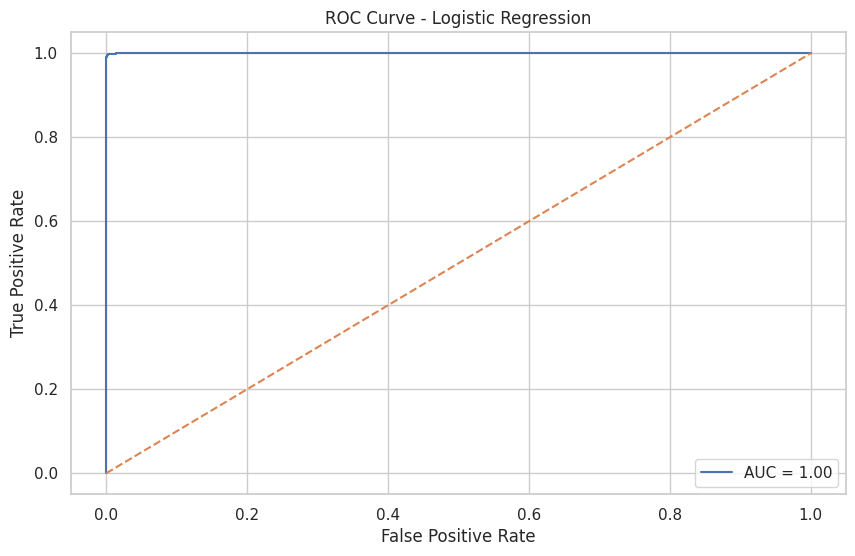


================ Random Forest ================

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4411
           1       1.00      1.00      1.00      8443

    accuracy                           1.00     12854
   macro avg       1.00      1.00      1.00     12854
weighted avg       1.00      1.00      1.00     12854



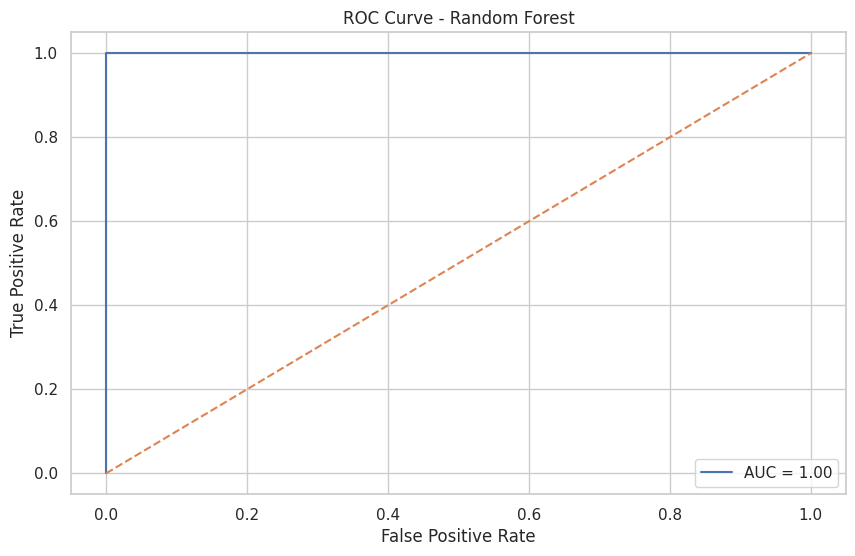


================ Naive Bayes ================

Accuracy: 0.9193247238213785

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      4411
           1       0.93      0.95      0.94      8443

    accuracy                           0.92     12854
   macro avg       0.91      0.91      0.91     12854
weighted avg       0.92      0.92      0.92     12854



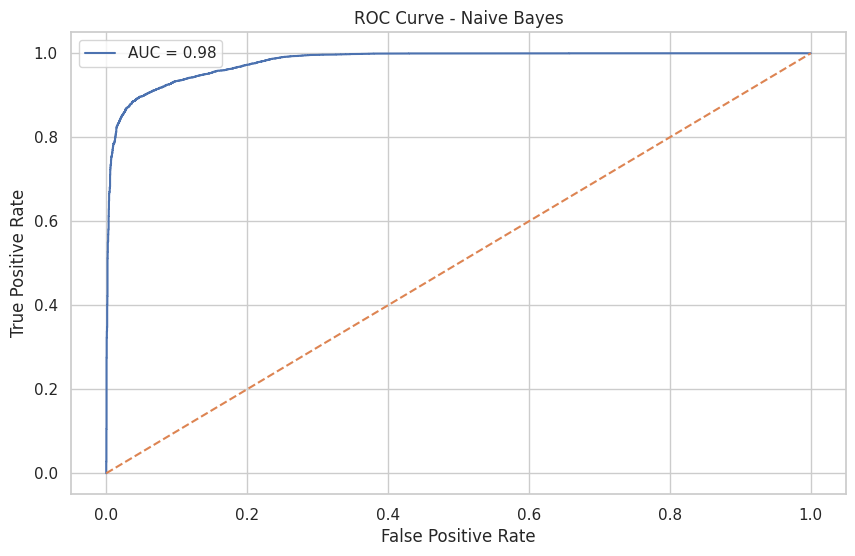

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB


# ======================================
# TARGET CREATION
# ======================================
# Example: Predict whether retraction is FAST or SLOW
df['target'] = (df['years_to_retraction'] <= 2).astype(int)

# ======================================
# DROP IRRELEVANT / LEAKAGE COLUMNS
# ======================================
drop_cols = [
    'record_id', 'title', 'journal', 'publisher', 'author',
    'reason', 'retractiondate', 'retractiondoi',
    'retractionpubmedid', 'originalpaperdate',
    'originalpaperdoi', 'originalpaperpubmedid'
]

df = df.drop(columns=drop_cols, errors='ignore')

# ======================================
# HANDLE MISSING VALUES
# ======================================
df = df.dropna()

# ======================================
# SPLIT FEATURES & TARGET
# ======================================
X = df.drop('target', axis=1)
y = df['target']

# ======================================
# TRAIN TEST SPLIT (NO DATA LEAKAGE)
# ======================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================
# LABEL ENCODING (FIT ONLY ON TRAIN)
# ======================================
cat_cols = X_train.select_dtypes(include='object').columns

le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen labels in test
    X_test[col] = X_test[col].map(
        lambda s: s if s in le.classes_ else 'UNK'
    )
    
    le.classes_ = np.append(le.classes_, 'UNK')
    X_test[col] = le.transform(X_test[col])
    
    le_dict[col] = le

# ======================================
# FEATURE SCALING (ONLY NUMERIC)
# ======================================
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# ======================================
# MODELS
# ======================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

# ======================================
# TRAINING + EVALUATION
# ======================================
for name, model in models.items():
    
    print(f"\n================ {name} ================\n")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    
    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    # ======================================
    # ROC CURVE
    # ======================================
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')
    
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!!!!